In [175]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

def scheduler(alpha, t): return alpha / (0.5*t+1)**0.5
def get_scheduler(val): return lambda alpha, t: alpha / (val*t+1)**0.5

params = Params(
    model_name="CliffSimple",
    n_runs=3,
    n_episodes=50_000,
    save_skip=100,
    lr_decay=None,
    seed=123,
    
    N=32,
    # alpha=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.5,1.8,2.0,5.0],
    alpha=1.0,
    gamma=0.99,
    epsilon=0.1,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(
    params.model_name,
    shape=(3,5),
)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = None
# save_to = "experiments/"+params.model_name

In [ ]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(params.epsilon, rng)

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

table_qr = QR(0, params, policy).train(env, explorer, get_exp_scheduler(0.5, 2000))

100%|██████████| 150000/150000 [04:20<00:00, 575.39it/s, run=3, t=5e+4] 


In [117]:
returns = MonteCarlo(env, policy, params.gamma, total_episodes=10_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 10000/10000 [00:00<00:00, 10548.48it/s]


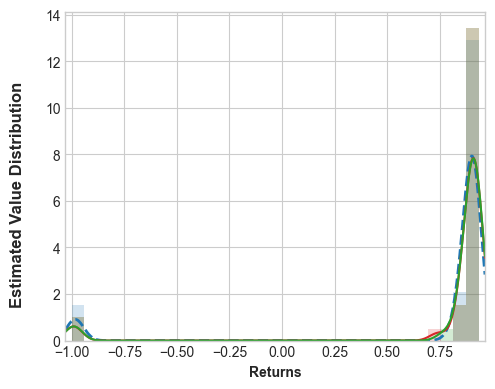

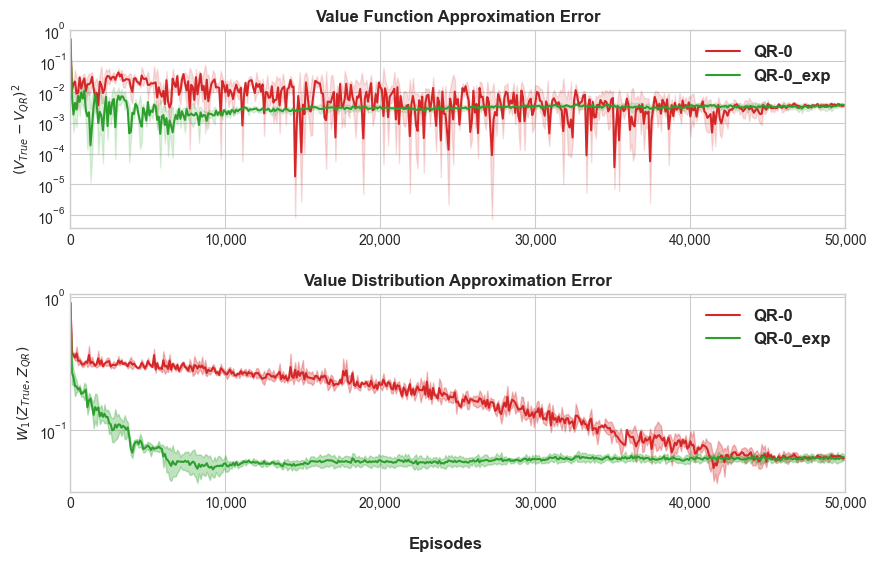

In [ ]:
def get_q(table): return table[:,:,s_init].max(2)
def get_best(table): return get_q(table)[:,-1].mean(0)

plot_objs = [
    (get_best(table_qr), "QR-0"),
]
plot_qs = [
    (get_q(table_qr), "QR-0"),
]
plot_pdf(plot_objs, tau_returns, bandwidth=0.04, show_hist=True, N=params.N, save_to=save_to)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.15,0.3])

In [131]:
import old.testing.display_qtables
importlib.reload(old.testing.display_qtables)
from old.testing.display_qtables import *

t_states = env.unwrapped._is_terminal.flatten()
display_qtables(table_qr.mean((0,-1)), params, highlight_optimal=False, decimals=2, margin=35, terminal_states=t_states)

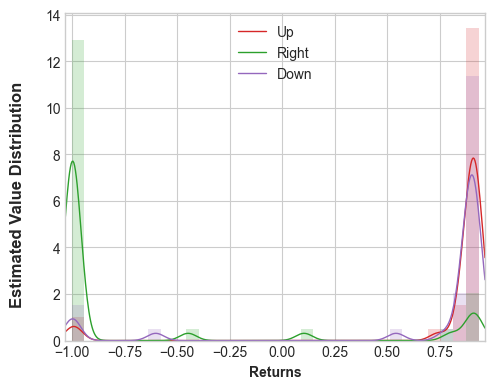

In [169]:
import analysis
importlib.reload(analysis)
from analysis import *

plot_objs = [
    (get_best(table_qr[:,:,:,0:1]), "Up"),
    (get_best(table_qr[:,:,:,1:2]), "Right"),
    (get_best(table_qr[:,:,:,2:3]), "Down"),
    # (get_best(table_qr[:,:,:,3:4]), "Left"),
]
plot_pdf(plot_objs, bandwidth=0.04, show_hist=True, N=params.N, save_to=save_to)
plt.legend();

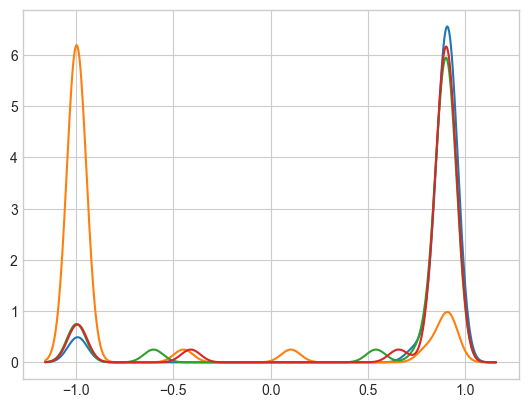

In [ ]:
Xs = np.linspace(-1.16, 1.16, 500)
for a_quantiles in table_qr.mean(0)[-1][s_init]:
    plt.plot(Xs, get_kde(a_quantiles, 0.05)(Xs))
    plt.hist